In [3]:
import numpy as np
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod
from typing import Callable

class GridConfig:
    """Настройки пространственной и временной сетки"""
    def __init__(self, x1: float, x2: float, t1: float, t2: float, nx: int, courant: float):
        self.x = np.linspace(x1, x2, nx)
        self.nx = nx
        self.dx = (x2 - x1) / (nx - 1)
        self.courant = courant
        self.c = 1.0
        self.dt = courant * self.dx / self.c
        self.t = np.arange(t1, t2 + self.dt, self.dt)
        self.nt = len(self.t)


In [4]:
class WaveFunctions:
    """Функции для волнового уравнения"""
    def __init__(self, k: int = 1):
        self.k = k
    def initial_condition(self, x: np.ndarray) -> np.ndarray:
        return np.sin(self.k * np.pi * x)
    def initial_speed(self, x: np.ndarray) -> np.ndarray:
        return np.sin(self.k * np.pi * x)
    def exact_solution(self, x: np.ndarray, t: float) -> np.ndarray:
        k = self.k
        return np.sin(k * np.pi * x) * (np.cos(k * np.pi * t) + (1/np.pi) * np.sin(k * np.pi * t))


In [5]:
class BaseSolver(ABC):
    def __init__(self, grid: GridConfig, funcs: WaveFunctions):
        self.grid = grid
        self.funcs = funcs
    @abstractmethod
    def solve(self) -> np.ndarray:
        pass


In [6]:
class ExplicitWaveSolver(BaseSolver):
    def solve(self) -> np.ndarray:
        nx, nt = self.grid.nx, self.grid.nt
        u = np.zeros((nt, nx))
        x = self.grid.x
        dt = self.grid.dt
        dx = self.grid.dx
        courant = self.grid.courant
        # Начальные условия
        u[0, :] = self.funcs.initial_condition(x)
        u[1, 1:-1] = u[0, 1:-1] + dt * self.funcs.initial_speed(x[1:-1]) + \
            0.5 * (courant ** 2) * (u[0, 2:] - 2 * u[0, 1:-1] + u[0, :-2])
        u[1, 0] = u[1, -1] = 0.0
        # Временной цикл
        for n in range(1, nt - 1):
            u[n + 1, 1:-1] = 2 * u[n, 1:-1] - u[n - 1, 1:-1] + \
                (courant ** 2) * (u[n, 2:] - 2 * u[n, 1:-1] + u[n, :-2])
            u[n + 1, 0] = u[n + 1, -1] = 0.0
        return u


In [7]:
class SolutionPlotter:
    def plot(self, grid: GridConfig, u: np.ndarray, funcs: WaveFunctions):
        t_indices = [0, grid.nt//4, grid.nt//2, 3*grid.nt//4, grid.nt-1]
        plt.figure(figsize=(10,6))
        for idx in t_indices:
            plt.plot(grid.x, u[idx, :], label=f'Num t={grid.t[idx]:.2f}')
            plt.plot(grid.x, funcs.exact_solution(grid.x, grid.t[idx]), '--', alpha=0.7)
        plt.xlabel('x')
        plt.ylabel('u(x,t)')
        plt.title('Численное и точное решение')
        plt.legend()
        plt.grid(True)
        plt.show()


In [8]:
def demonstrate_dispersion(solver: ExplicitWaveSolver, k: int = 5):
    """
    Демонстрируем численную дисперсию:
    Берём высокочастотное начальное условие (k>1) и сравниваем фазовые скорости
    """
    solver.funcs.k = k
    u = solver.solve()
    grid = solver.grid
    # Сравниваем максимум волны в численном и точном решении
    num_peak_pos = grid.x[np.argmax(u[-1, :])]
    exact_peak_pos = grid.x[np.argmax(solver.funcs.exact_solution(grid.x, grid.t[-1]))]
    phase_shift = num_peak_pos - exact_peak_pos
    # Визуализация
    plt.figure(figsize=(8,5))
    plt.plot(grid.x, u[-1, :], label='Численное решение')
    plt.plot(grid.x, solver.funcs.exact_solution(grid.x, grid.t[-1]), '--', label='Точное решение')
    plt.xlabel('x')
    plt.ylabel('u(x, t_final)')
    plt.title(f'Дисперсия: k={k}, Courant={grid.courant}\nФазовый сдвиг: {phase_shift:.2e}')
    plt.legend()
    plt.grid()
    plt.show()
    print(f'Численная дисперсия: фазовый сдвиг = {phase_shift:.2e}')


## Нормальное решение

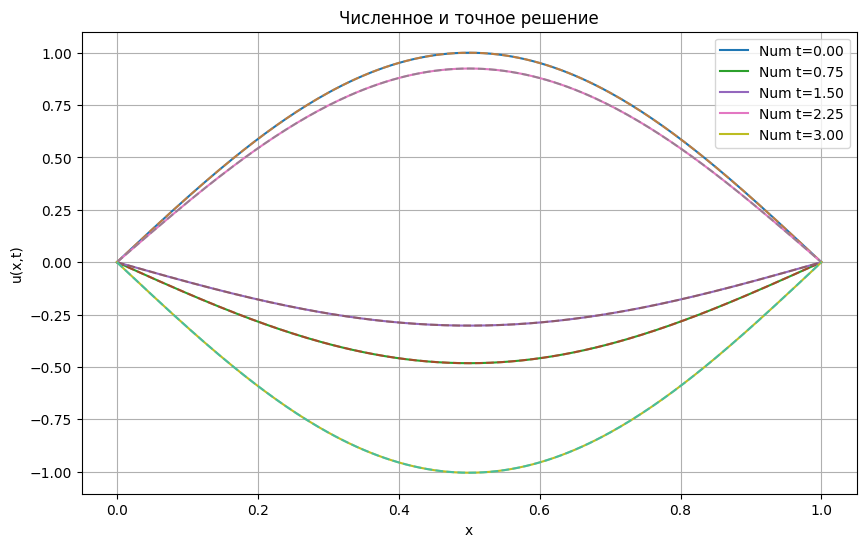

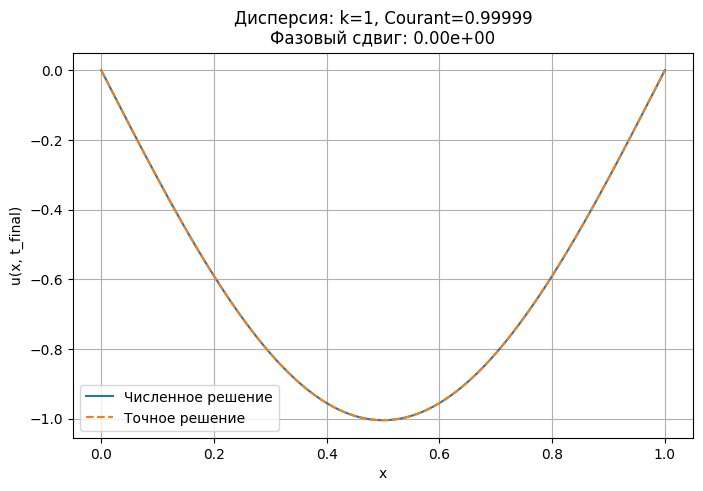

Численная дисперсия: фазовый сдвиг = 0.00e+00


In [88]:
if __name__ == "__main__":
    # Конфигурация
    grid = GridConfig(x1=0, x2=1, t1=0, t2=3, nx=201, courant=0.99999)
    funcs = WaveFunctions(k=1)
    solver = ExplicitWaveSolver(grid, funcs)
    u = solver.solve()
    # Визуализация
    plotter = SolutionPlotter()
    plotter.plot(grid, u, funcs)
    # Демонстрируем численную дисперсию для коротких волн:
    demonstrate_dispersion(solver, k=1)


In [10]:
import numpy as np
import matplotlib.pyplot as plt

def smooth_delta(x, center=0.5, width=0.03, height=1.0):
    """Сглаженный аналог дельта-функции — узкая шапочка из cos'а."""
    envelope = np.abs(x - center) < width
    profile = np.zeros_like(x)
    profile[envelope] = height * 0.5 * (1 + np.cos(np.pi * (x[envelope] - center) / width))
    return profile

def initial_gaussian(x, center=0.5, sigma=0.02):
    """Гауссов пакет с центром center и шириной sigma"""
    return np.exp(-(x - center)**2 / (2 * sigma**2))


## Фазовая скорость

In [101]:
import numpy as np
import matplotlib.pyplot as plt

def demonstrate_dispersion_delta(solver, courant=1, nx=201, width=0.02, height=1.0, T=2):
    # Установка грид-сетки
    grid = solver.grid
    if nx is not None:
        grid = GridConfig(x1=0, x2=1, t1=0, t2=T, nx=nx, courant=courant)
        solver.grid = grid
    # Начальные условия: сглаженная дельта в центре (нулевое смещение, не нулевая скорость!)
    center = 0.5
    solver.funcs.initial_condition = lambda x: smooth_delta(x, center=center, width=width, height=height)
    solver.funcs.initial_speed = lambda x: np.zeros_like(x)
    u = solver.solve()
    # Временные слои для визуализации
    times_to_plot = [0, grid.nt//10, grid.nt//4, grid.nt//2, grid.nt-1]
    plt.figure(figsize=(9,6))
    for idx in times_to_plot:
        plt.plot(grid.x, u[idx, :], label=f"t={grid.t[idx]:.2f}")
    plt.title('Численная дисперсия: Распространение сглаженной дельты')
    plt.xlabel('x')
    plt.ylabel('u(x,t)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- ВЫЧИСЛЕНИЕ ЧИСЛЕННОЙ ФАЗОВОЙ СКОРОСТИ ---
    # Теория: на t>0 дельта делится на две волны, бегущие влево и вправо.
    # Удобно отслеживать максимум правой половинки.
    idx0 = np.argmax(u[0, :])  # в момент t=0 максимум
    idx_last = np.argmax(u[-1, :])  # на последнем временном слое максимум
    x0 = grid.x[idx0]
    x_last = grid.x[idx_last]
    t0 = grid.t[0]
    t_last = grid.t[-1]
    v_phase_num = (x_last - x0) / (t_last - t0)
    v_phase_analytic = 1.0  # по определению для этой задачи
    delta_v = v_phase_analytic - v_phase_num

    print(f"Число Куранта: {courant:.5f}")

    return v_phase_num, v_phase_analytic, delta_v


In [50]:
def demonstrate_dispersion_gaussian(solver, courant=1, nx=201, sigma=0.02, T=None):
    grid = solver.grid
    if nx is not None:
        grid = GridConfig(x1=0, x2=1, t1=0, t2=solver.grid.t[-1] if T is None else T, nx=nx, courant=courant)
        solver.grid = grid
    solver.funcs.initial_condition = lambda x: initial_gaussian(x, sigma=sigma)
    solver.funcs.initial_speed = lambda x: np.zeros_like(x)
    u = solver.solve()
    times_to_plot = [0, grid.nt//10, grid.nt//4, grid.nt//2, grid.nt-1]
    plt.figure(figsize=(9,6))
    for idx in times_to_plot:
        plt.plot(grid.x, u[idx, :], label=f"t={grid.t[idx]:.2f}")
    plt.title('Численная дисперсия: Распространение Гауссиана')
    plt.xlabel('x')
    plt.ylabel('u(x,t)')
    plt.legend()
    plt.grid(True)
    plt.show()


## Дельта-функция

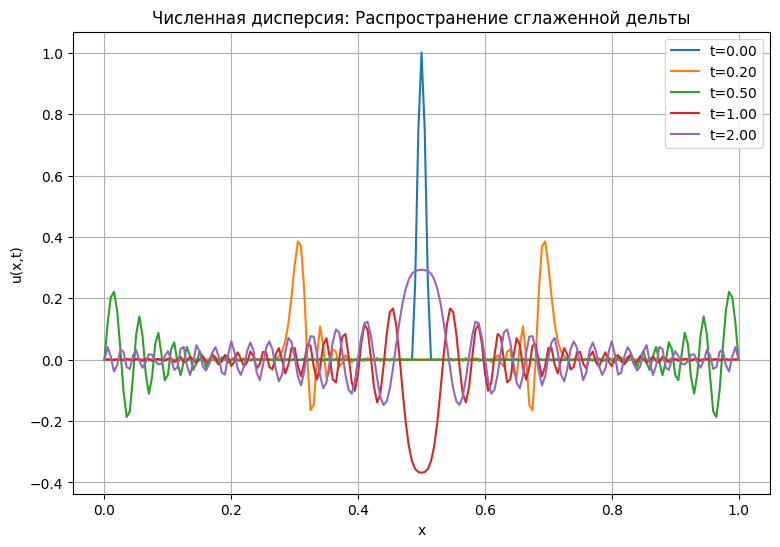

Число Куранта: 0.20000


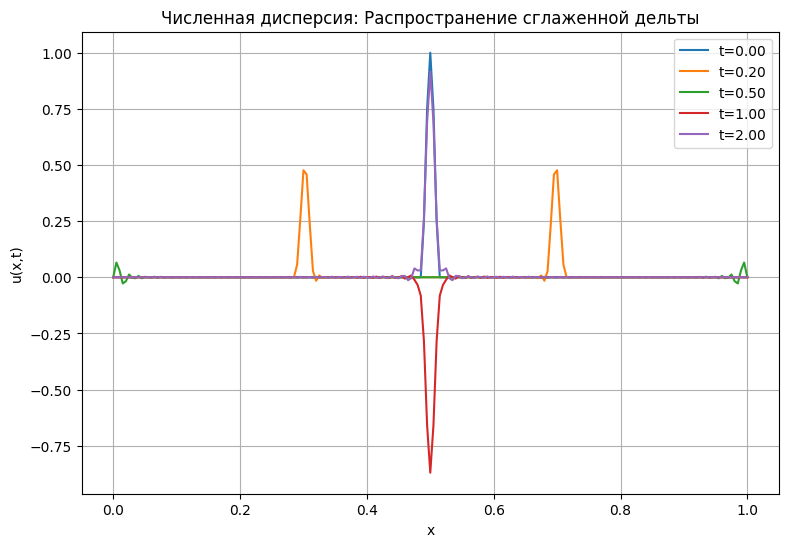

Число Куранта: 0.99000


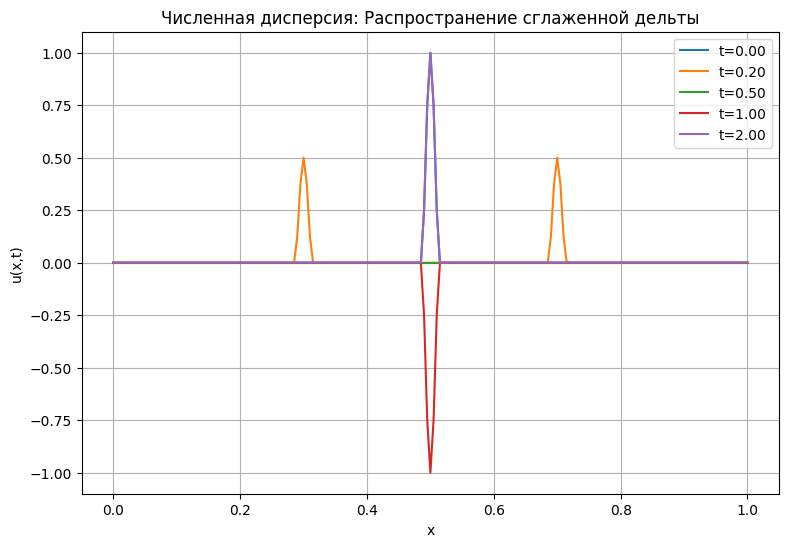

Число Куранта: 1.00000


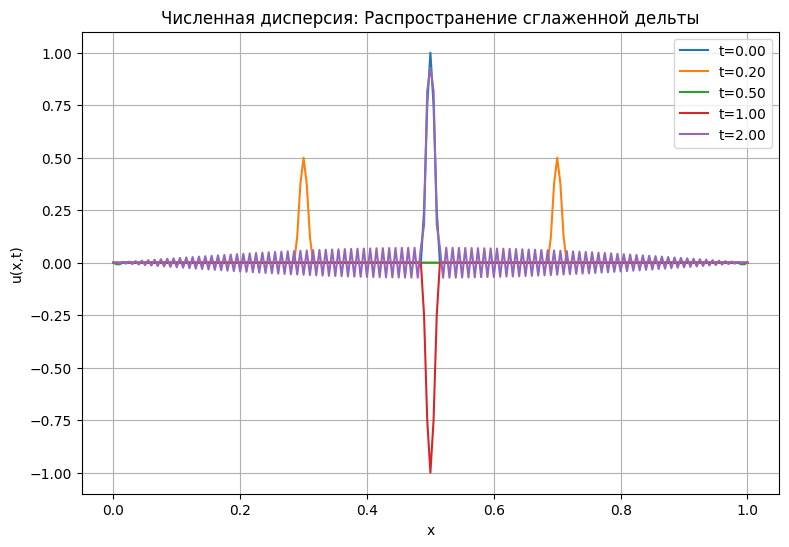

Число Куранта: 1.00015


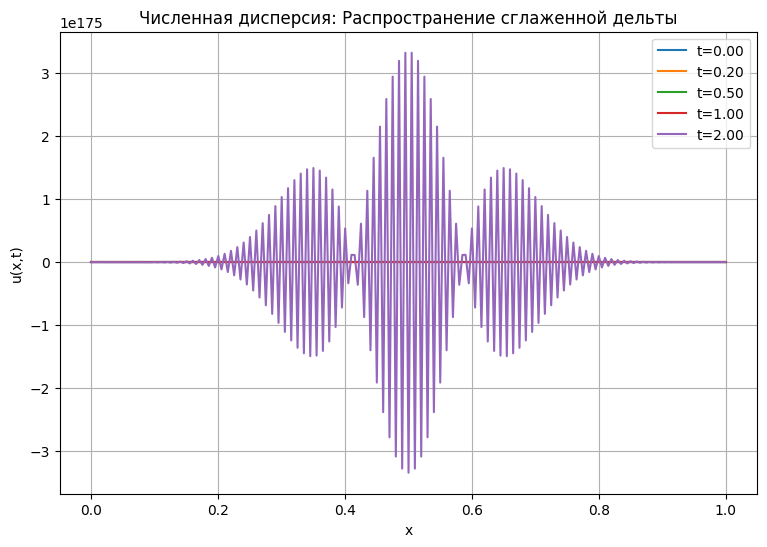

Число Куранта: 1.20000


(0.0024950099800399223, 1.0, 0.9975049900199601)

In [103]:
# solver – уже созданный экземпляр класса с grid, funcs и solve()
demonstrate_dispersion_delta(solver, courant=0.2, nx=201, width=0.015)
demonstrate_dispersion_delta(solver, courant=0.99, nx=201, width=0.015)
demonstrate_dispersion_delta(solver, courant=1, nx=201, width=0.015)
demonstrate_dispersion_delta(solver, courant=1.00015, nx=201, width=0.015)
demonstrate_dispersion_delta(solver, courant=1.2, nx=201, width=0.015)

In [14]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

def animate_dispersion_delta(solver, nx=201, width=0.02, height=1.0, gif_name='delta_dispersion.gif', fps=20):
    grid = solver.grid
    # Подготовить новую сетку при необходимости
    if nx != solver.grid.nx:
        grid = GridConfig(x1=0, x2=1, t1=0, t2=solver.grid.t[-1], nx=nx, courant=solver.grid.courant)
        solver.grid = grid
    # Начальные условия
    solver.funcs.initial_condition = lambda x: smooth_delta(x, width=width, height=height)
    solver.funcs.initial_speed = lambda x: np.zeros_like(x)
    u = solver.solve()
    fig, ax = plt.subplots(figsize=(8, 5))
    line, = ax.plot([], [], 'b-', lw=2)
    ax.set_xlim(grid.x[0], grid.x[-1])
    ax.set_ylim(-1.05, 1.05*height)
    ax.set_xlabel('x')
    ax.set_ylabel('u(x,t)')
    ax.set_title('Дисперсия: Сглаженная дельта')
    
    def init():
        line.set_data([], [])
        return (line,)
    def animate(n):
        line.set_data(grid.x, u[n, :])
        ax.set_title(f'Сглаженная дельта, t={grid.t[n]:.2f}')
        return (line,)
    ani = animation.FuncAnimation(fig, animate, frames=grid.nt, init_func=init,
                                  interval=40, blit=True)
    ani.save(gif_name, writer=animation.PillowWriter(fps=fps))
    plt.close(fig)
    print(f'GIF сохранён: {gif_name}')


In [15]:
def animate_dispersion_gaussian(solver, nx=201, sigma=0.02, gif_name='gaussian_dispersion.gif', fps=20):
    grid = solver.grid
    if nx != solver.grid.nx:
        grid = GridConfig(x1=0, x2=1, t1=0, t2=solver.grid.t[-1], nx=nx, courant=solver.grid.courant)
        solver.grid = grid
    solver.funcs.initial_condition = lambda x: initial_gaussian(x, sigma=sigma)
    solver.funcs.initial_speed = lambda x: np.zeros_like(x)
    u = solver.solve()
    fig, ax = plt.subplots(figsize=(8, 5))
    line, = ax.plot([], [], 'r-', lw=2)
    ax.set_xlim(grid.x[0], grid.x[-1])
    ax.set_ylim(-1.05, 1.05)
    ax.set_xlabel('x')
    ax.set_ylabel('u(x,t)')
    ax.set_title('Дисперсия: Гауссиан')
    
    def init():
        line.set_data([], [])
        return (line,)
    def animate(n):
        line.set_data(grid.x, u[n, :])
        ax.set_title(f'Гауссиан, t={grid.t[n]:.2f}')
        return (line,)
    ani = animation.FuncAnimation(fig, animate, frames=grid.nt, init_func=init,
                                  interval=40, blit=True)
    ani.save(gif_name, writer=animation.PillowWriter(fps=fps))
    plt.close(fig)
    print(f'GIF сохранён: {gif_name}')


In [16]:
# Допустим, solver — экземпляр вашего численного класса
animate_dispersion_delta(solver, nx=201, width=0.02, height=1.0, gif_name='delta_dispersion.gif')
animate_dispersion_gaussian(solver, nx=201, sigma=0.02, gif_name='gaussian_dispersion.gif')


GIF сохранён: delta_dispersion.gif
GIF сохранён: gaussian_dispersion.gif


In [70]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def animate_fft_evolution(solver, gif_name='fft_evolution.gif', fps=20):
    """
    Анимация изменения спектра (FFT) решения по времени для результата с солвера.
    """
    u = solver.solve()  # [nt, nx]
    grid = solver.grid
    nt = grid.nt
    nx = grid.nx
    dx = grid.dx
    t_arr = grid.t

    # Создаем ось волновых чисел (k)
    k = np.fft.fftfreq(nx, d=dx)
    k = np.fft.fftshift(k)

    fig, ax = plt.subplots(figsize=(9, 5))
    line, = ax.plot([], [], 'b-', lw=2)
    ax.set_xlim(-150, 150)
    ax.set_ylim(0, 1.2 )
    ax.set_xlabel('Волновое число k')
    ax.set_ylabel('Амплитуда |FFT|')
    ax.set_title('Изменение спектра решения')

    def init():
        line.set_data([], [])
        return (line,)
    def animate(n):
        spectrum = np.fft.fft(u[n, :])
        spectrum = np.fft.fftshift(np.abs(spectrum)/np.abs(np.max(spectrum)))
        line.set_data(k, spectrum)
        ax.set_title(f'FFT спектр, t={t_arr[n]:.3f}')
        return (line,)
    anim = animation.FuncAnimation(fig, animate, frames=nt, init_func=init,
                                  interval=40, blit=True)
    anim.save(gif_name, writer=animation.PillowWriter(fps=fps))
    plt.close(fig)
    print(f'Анимация FFT спектра сохранена: {gif_name}')


## Первая анимация

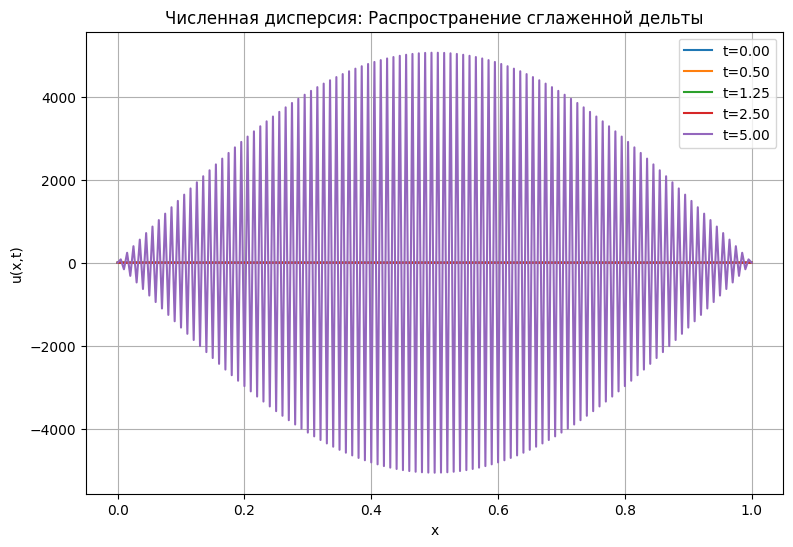

Численная фазовая скорость: 0.00100
Аналитическая фазовая скорость: 1.00000
Разница фазовых скоростей: 9.99000e-01 (99.900% отклонение)


KeyboardInterrupt: 

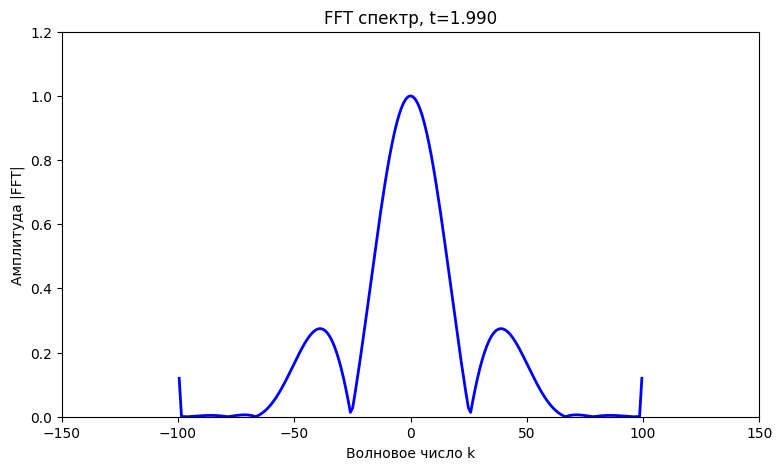

In [80]:
demonstrate_dispersion_delta(solver, courant=1.0001, nx=201, width=0.015, T = 5)

animate_fft_evolution(solver, gif_name='fft_evolution.gif', fps=20)


In [84]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def animate_fft_evolution_wide(solver, gif_name='fft_evolution.gif', fps=20, kmax_vis=None, show_full_range=True):
    """
    Анимация изменения спектра (FFT) решения по времени для результата с солвера.
    Диапазон оси k либо задаётся вручную, либо охватывает весь спектр по сетке.
    """
    u = solver.solve()  # [nt, nx]
    grid = solver.grid
    nt = grid.nt
    nx = grid.nx
    dx = grid.dx
    t_arr = grid.t

    # Волновые числа
    k = np.fft.fftfreq(nx, d=dx) * 2 * np.pi  # теперь в радианах (по желанию)
    k = np.fft.fftshift(k)
    norm_factor = np.max(np.abs(np.fft.fft(u[0, :])))
    # Визуализируемый диапазон
    if kmax_vis is not None:
        kmin = -kmax_vis
        kmax = kmax_vis
    elif show_full_range:
        kmin = k[0]
        kmax = k[-1]
    else:
        # по дефолту ±20% ширины Найквиста
        k_nyquist = np.pi / dx
        kmin = -1.2*k_nyquist
        kmax = 1.2*k_nyquist

    fig, ax = plt.subplots(figsize=(10, 5))
    line, = ax.plot([], [], 'b-', lw=2)
    ax.set_xlim(kmin, kmax)
    ax.set_ylim(0, 3)
    ax.set_xlabel('Волновое число k')
    ax.set_ylabel('Отн. амплитуда |FFT|')
    ax.set_title('Изменение спектра решения')

    def init():
        line.set_data([], [])
        return (line,)

    def animate(n):
        spectrum = np.fft.fft(u[n, :])
        spectrum = np.fft.fftshift(np.abs(spectrum) / norm_factor)
        line.set_data(k, spectrum)
        ax.set_title(f'FFT спектр, t={t_arr[n]:.3f}')
        return (line,)

    anim = animation.FuncAnimation(
        fig, animate, frames=nt, init_func=init, interval=40, blit=True
    )
    anim.save(gif_name, writer=animation.PillowWriter(fps=fps))
    plt.close(fig)
    print(f'Анимация FFT спектра сохранена: {gif_name}')




## Анимация преобразования Фурье

In [89]:
animate_fft_evolution_wide(solver, gif_name='fft_wide.gif', fps=20, kmax_vis=None, show_full_range=True)

Анимация FFT спектра сохранена: fft_wide.gif


### Анимация спектра стоячей волны 


#### Число Куранта 1.001

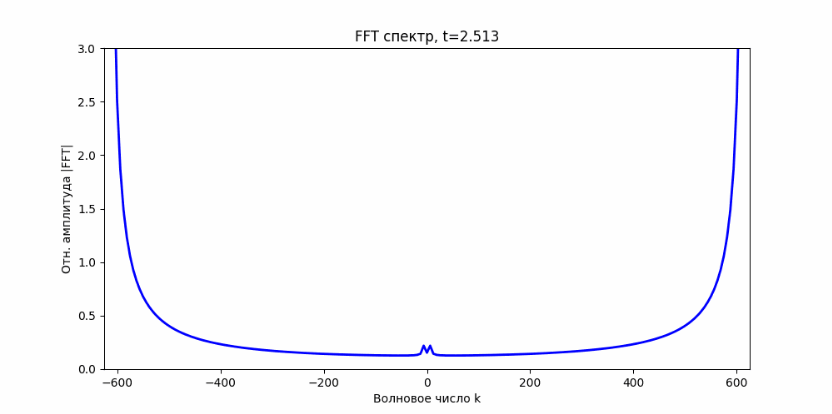

#### Число Куранта 0.2

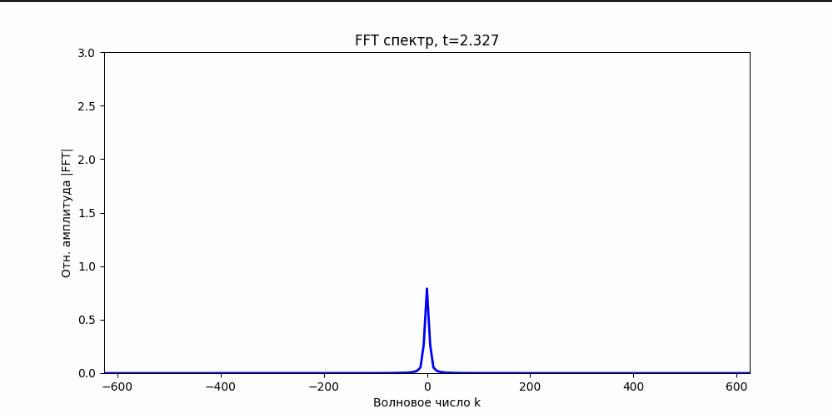

Анализ решения:
  max_amplitude: 1.049424137314598
  min_amplitude: -1.0494239418688798
  max_amplitude_time_index: 420
  energy_norm: 0.8310063126283295
  stability_condition: Courant = 1.000
  is_stable: True


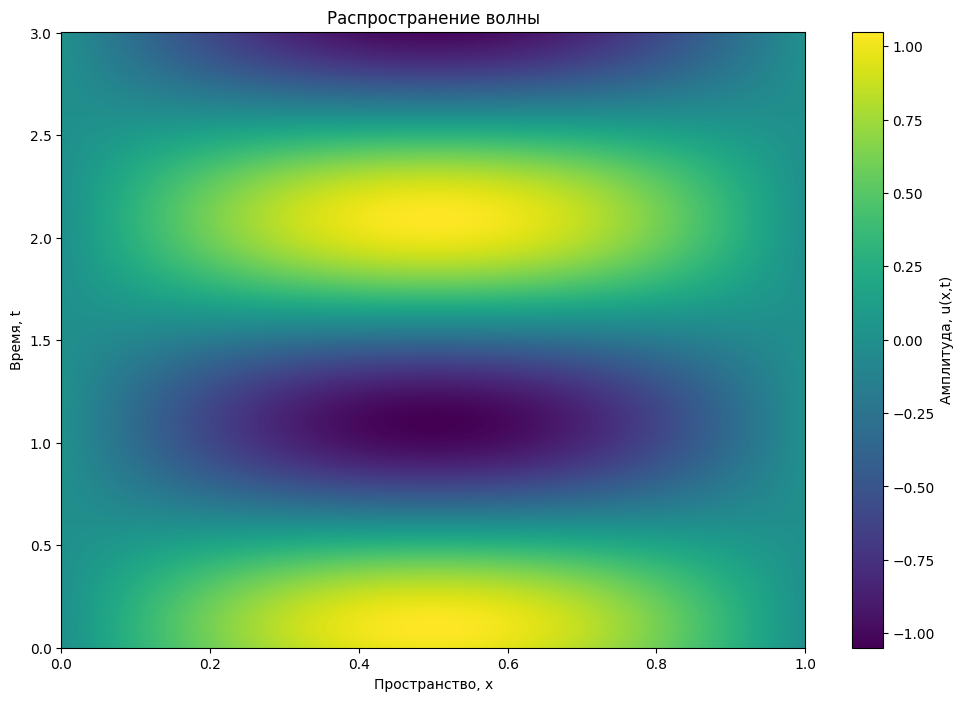

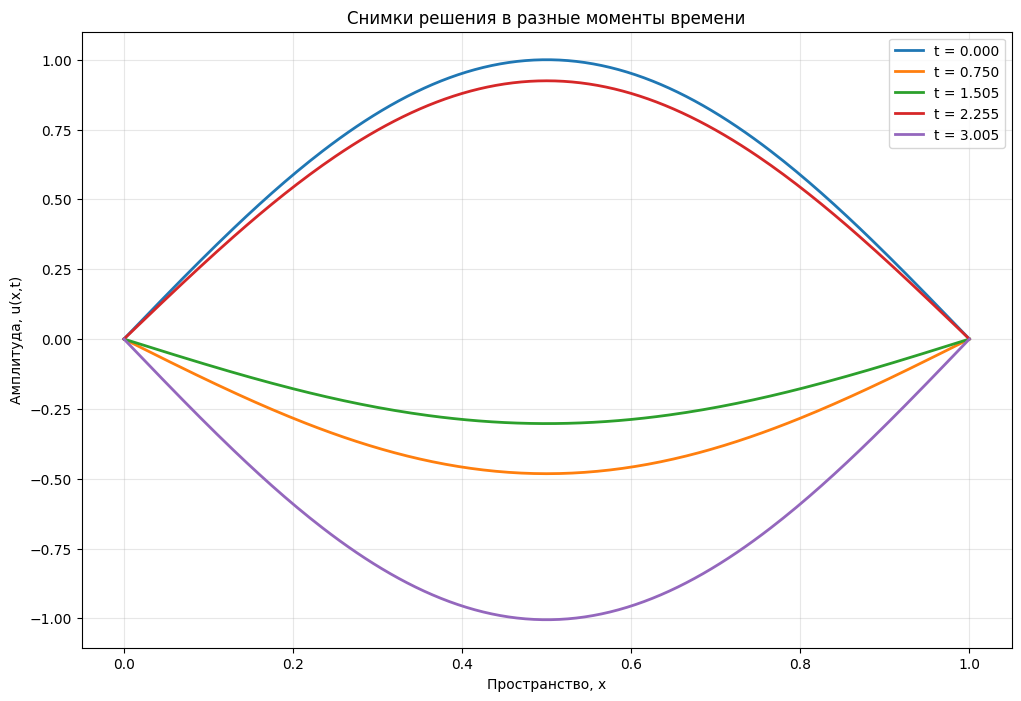

In [105]:
import numpy as np
from typing import Tuple, Optional
import matplotlib.pyplot as plt

class ExplicitWaveSolver(BaseSolver):
    def solve(self) -> np.ndarray:
        """
        Решает волновое уравнение и возвращает двумерный массив u[time, space]
        где координаты представляют собой карту время-пространство.
        
        Returns:
            np.ndarray: 2D массив формы (nt, nx) с решением волнового уравнения
        """
        nx, nt = self.grid.nx, self.grid.nt
        u = np.zeros((nt, nx))
        x = self.grid.x
        dt = self.grid.dt
        dx = self.grid.dx
        courant = self.grid.courant
        
        # Валидация параметров
        if courant >= 1.0:
            print(f"Предупреждение: Число Куранта = {courant:.3f} >= 1.0, решение может быть неустойчивым")
        
        # Начальные условия в момент времени t=0
        u[0, :] = self.funcs.initial_condition(x)
        
        # Первый шаг по времени (используем разложение Тейлора)
        u[1, 1:-1] = (u[0, 1:-1] + 
                      dt * self.funcs.initial_speed(x[1:-1]) + 
                      0.5 * (courant ** 2) * (u[0, 2:] - 2 * u[0, 1:-1] + u[0, :-2]))
        
        # Граничные условия (закрепленные концы)
        u[1, 0] = u[1, -1] = 0.0
        
        # Основной временной цикл
        for n in range(1, nt - 1):
            # Явная схема для внутренних точек
            u[n + 1, 1:-1] = (2 * u[n, 1:-1] - u[n - 1, 1:-1] + 
                             (courant ** 2) * (u[n, 2:] - 2 * u[n, 1:-1] + u[n, :-2]))
            
            # Граничные условия
            u[n + 1, 0] = u[n + 1, -1] = 0.0
        
        return u
    
    def get_time_space_coordinates(self) -> Tuple[np.ndarray, np.ndarray]:
        """
        Возвращает координаты времени и пространства для построения карты.
        
        Returns:
            Tuple[np.ndarray, np.ndarray]: (time_array, space_array)
        """
        time_coords = np.arange(self.grid.nt) * self.grid.dt
        space_coords = self.grid.x
        return time_coords, space_coords
    
    def plot_time_space_map(self, u: np.ndarray, title: str = "Карта решения: время-пространство", 
                           cmap: str = 'viridis', figsize: Tuple[int, int] = (12, 8)) -> plt.Figure:
        """
        Строит двумерную карту решения в координатах время-пространство.
        
        Args:
            u: Решение волнового уравнения (2D массив)
            title: Заголовок графика
            cmap: Цветовая карта
            figsize: Размер фигуры
            
        Returns:
            plt.Figure: Объект фигуры
        """
        time_coords, space_coords = self.get_time_space_coordinates()
        
        fig, ax = plt.subplots(figsize=figsize)
        
        # Создаем тепловую карту
        im = ax.imshow(u, aspect='auto', origin='lower', 
                      extent=[space_coords[0], space_coords[-1], 
                              time_coords[0], time_coords[-1]],
                      cmap=cmap)
        
        ax.set_xlabel('Пространство, x')
        ax.set_ylabel('Время, t')
        ax.set_title(title)
        
        # Добавляем цветовую шкалу
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Амплитуда, u(x,t)')
        
        return fig
    
    def plot_snapshot_comparison(self, u: np.ndarray, 
                               time_indices: Optional[list] = None,
                               figsize: Tuple[int, int] = (12, 8)) -> plt.Figure:
        """
        Сравнивает снимки решения в разные моменты времени.
        
        Args:
            u: Решение волнового уравнения
            time_indices: Индексы временных срезов для отображения
            figsize: Размер фигуры
            
        Returns:
            plt.Figure: Объект фигуры
        """
        if time_indices is None:
            # По умолчанию показываем начальный, средний и конечный моменты времени
            time_indices = [0, self.grid.nt//4, self.grid.nt//2, 3*self.grid.nt//4, -1]
        
        time_coords, space_coords = self.get_time_space_coordinates()
        
        fig, ax = plt.subplots(figsize=figsize)
        
        for idx in time_indices:
            if idx < 0:
                idx = self.grid.nt + idx
            label = f't = {time_coords[idx]:.3f}'
            ax.plot(space_coords, u[idx, :], label=label, linewidth=2)
        
        ax.set_xlabel('Пространство, x')
        ax.set_ylabel('Амплитуда, u(x,t)')
        ax.set_title('Снимки решения в разные моменты времени')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        return fig
    
    def analyze_solution(self, u: np.ndarray) -> dict:
        """
        Анализирует решение и возвращает статистику.
        
        Args:
            u: Решение волнового уравнения
            
        Returns:
            dict: Словарь с аналитической информацией
        """
        analysis = {
            'max_amplitude': np.max(np.abs(u)),
            'min_amplitude': np.min(u),
            'max_amplitude_time_index': np.argmax(np.max(np.abs(u), axis=1)),
            'energy_norm': np.sum(u**2) * self.grid.dx * self.grid.dt,
            'stability_condition': f"Courant = {self.grid.courant:.3f}",
            'is_stable': self.grid.courant < 1.0
        }
        
        return analysis

# Пример использования:
if __name__ == "__main__":
    # После получения решения:
    grid = GridConfig(x1=0, x2=1, t1=0, t2=3, nx=201, courant=0.99999)
    funcs = WaveFunctions(k=1)
    solver = ExplicitWaveSolver(grid, funcs)

    u = solver.solve()
    
    # Построение карты время-пространство
    fig1 = solver.plot_time_space_map(u, "Распространение волны")
    
    # Сравнение снимков в разные моменты времени
    fig2 = solver.plot_snapshot_comparison(u)
    
    # Анализ решения
    stats = solver.analyze_solution(u)
    print("Анализ решения:")
    for key, value in stats.items():
        print(f"  {key}: {value}")
    
    plt.show()

### Двумерная карта решения

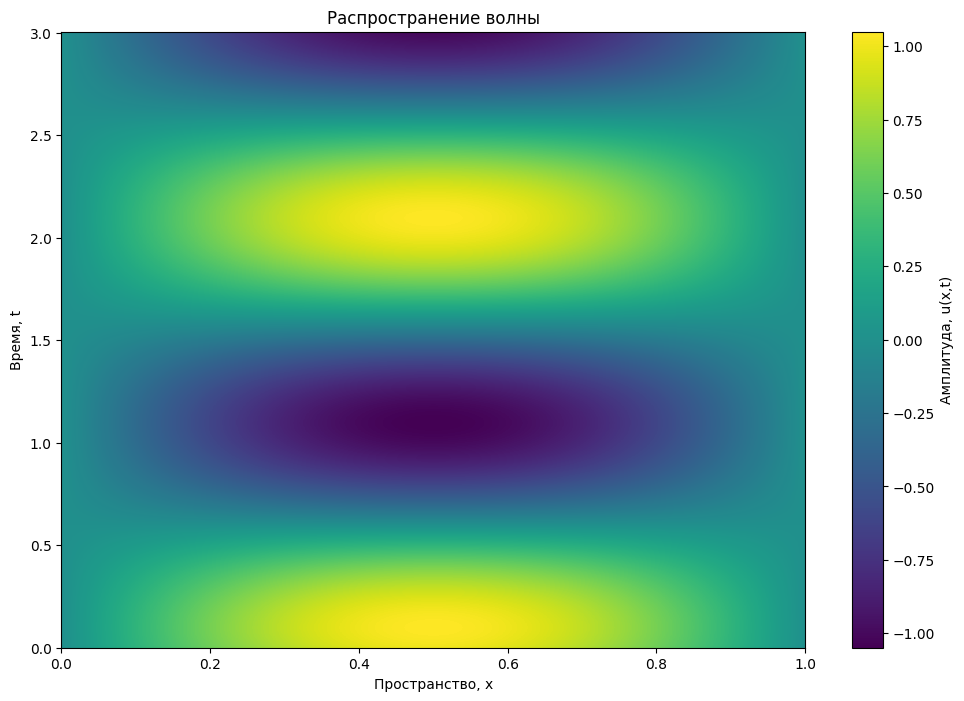

In [106]:
import numpy as np
import matplotlib.pyplot as plt

def plot_error_vs_time(solver, exact_solution_func=None, title="Максимальная ошибка во времени"):
    """
    Рисует график зависимости максимальной ошибки (по x) от времени.
    solver              — объект-солвер, у которого есть методы solve() и доступ к grid
    exact_solution_func — функция вида f(x, t), возвращает массив точного решения
    title               — заголовок для графика
    """
    u = solver.solve()  # численное решение: shape (nt, nx)
    grid = solver.grid
    t_arr = grid.t
    x_arr = grid.x
    nt = grid.nt

    if exact_solution_func is None:
        # По умолчанию ищем в solver.funcs
        exact_solution_func = solver.funcs.exact_solution

    errors = np.zeros(nt)
    for n in range(nt):
        exact = exact_solution_func(x_arr, t_arr[n])
        errors[n] = np.max(np.abs(u[n, :] - exact))

    plt.figure(figsize=(8, 4.5))
    plt.plot(t_arr, errors, 'r-', lw=2)
    plt.xlabel('Время t')
    plt.ylabel('Максимальная ошибка')
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return errors


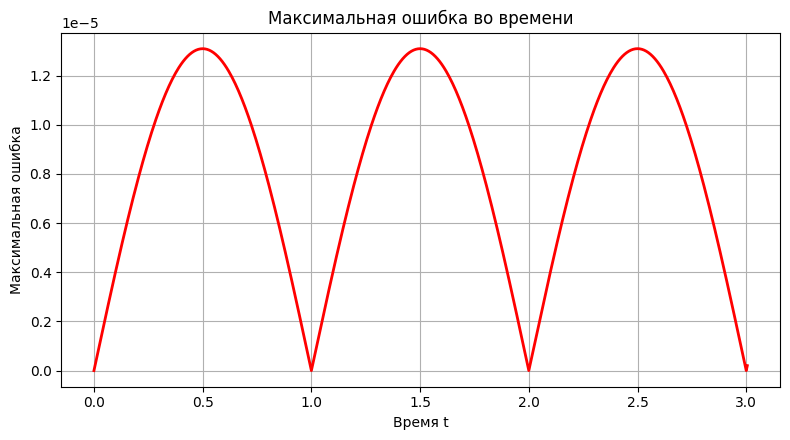

array([0.00000000e+00, 2.05608104e-07, 4.11165580e-07, 6.16621712e-07,
       8.21925808e-07, 1.02702721e-06, 1.23187532e-06, 1.43641960e-06,
       1.64060957e-06, 1.84439485e-06, 2.04772518e-06, 2.25055037e-06,
       2.45282039e-06, 2.65448533e-06, 2.85549544e-06, 3.05580112e-06,
       3.25535294e-06, 3.45410168e-06, 3.65199829e-06, 3.84899395e-06,
       4.04504006e-06, 4.24008823e-06, 4.43409036e-06, 4.62699857e-06,
       4.81876527e-06, 5.00934313e-06, 5.19868515e-06, 5.38674460e-06,
       5.57347509e-06, 5.75883054e-06, 5.94276521e-06, 6.12523373e-06,
       6.30619108e-06, 6.48559261e-06, 6.66339405e-06, 6.83955152e-06,
       7.01402159e-06, 7.18676118e-06, 7.35772769e-06, 7.52687892e-06,
       7.69417316e-06, 7.85956910e-06, 8.02302596e-06, 8.18450339e-06,
       8.34396156e-06, 8.50136112e-06, 8.65666324e-06, 8.80982959e-06,
       8.96082239e-06, 9.10960439e-06, 9.25613886e-06, 9.40038967e-06,
       9.54232120e-06, 9.68189845e-06, 9.81908698e-06, 9.95385294e-06,
      

In [148]:
# для стоячей волны:
plot_error_vs_time(solver)


In [146]:
import numpy as np
import matplotlib.pyplot as plt

def plot_relative_error_vs_time(solver, exact_solution_func=None, title="Максимальная относительная ошибка во времени"):
    """
    Рисует график зависимости максимальной относительной ошибки по x от времени.
    solver              — объект-солвер, у которого есть методы solve() и доступ к grid
    exact_solution_func — функция вида f(x, t), возвращает массив точного решения
    title               — заголовок для графика
    """
    u = solver.solve()  # численное решение: shape (nt, nx)
    grid = solver.grid
    t_arr = grid.t
    x_arr = grid.x
    nt = grid.nt

    if exact_solution_func is None:
        exact_solution_func = solver.funcs.exact_solution

    rel_errors = np.zeros(nt)
    eps = 1e-200
    for n in range(nt):
        exact = exact_solution_func(x_arr, t_arr[n])
        rel_error = np.abs(u[n, :] - exact) / (np.abs(exact) + eps)
        rel_errors[n] = np.max(rel_error)

    plt.figure(figsize=(8, 4.5))
    plt.plot(t_arr, rel_errors, 'b-', lw=2)
    plt.xlabel('Время t')
    plt.ylabel('Максимальная относительная ошибка')
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return rel_errors


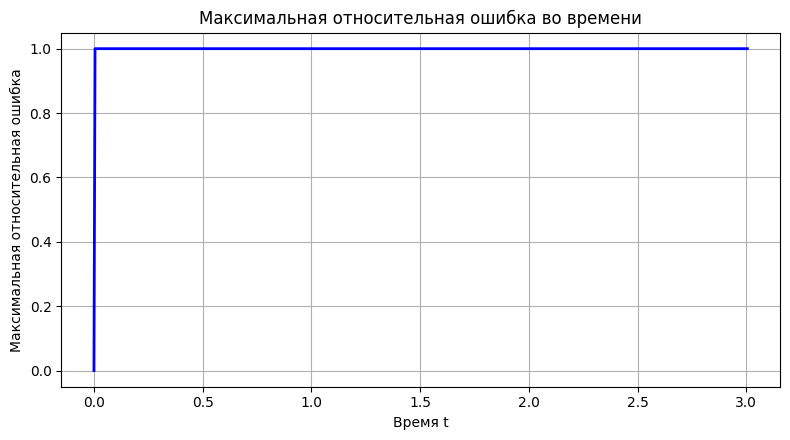

array([0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1.

In [147]:
plot_relative_error_vs_time(solver)
